In [5]:
import numpy as np
from scipy import fft, signal
import scipy as sp
from matplotlib import pyplot as plt
import matplotlib.animation

from IPython.display import HTML, Image

import schemdraw
from schemdraw import flow
import schemdraw as schem
import schemdraw.elements as e
from schemdraw import dsp

import io
import soundfile as sf
from urllib.request import urlopen

%config InlineBackend.figure_formats = ['svg']

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning)

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.RenderedHTMLCommon{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

# https://thewolfsound.com/bilinear-transform/




The estimation of a fundamental frequency in monophonic signals is a straight-forward (but still error-prone) procedure that can be done in multiple ways.

**Methods in the time domain:**

- Zero-Crossing Rate
- Autocorrelation Method

**Methods in the frequency domain:**

- Harmonic Product Spectrum
- Cepstral Analysis


----

# Autocorrelation method

The autocorrelation is a simple time-domain approach that is robust enough for high-SNR signals with a clear, stationary fundamental frequency.
The following example shows how the autocorrelation method works for a block of 2048 samples from a 
[violin sound](https://ringbuffer.org/download/ringbuffer_data/Sound_Synthesis_Introduction/Audio/SampLib_BuK_04.mp3), 
recorded at $48$ kHz.

We look for a peak in the autocorrelation signal $R_{XX}[n]$ and define a search range with:

$$
$f_{min}$ = 50 \mathrm{Hz}
$$

$$
$f_{max}$ = 1000 \mathrm{Hz}
$$

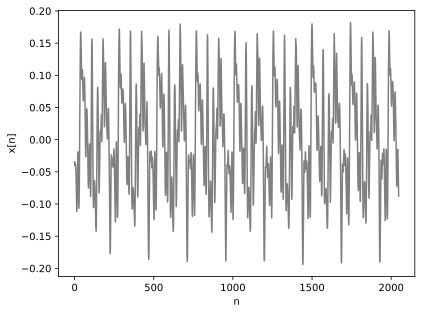

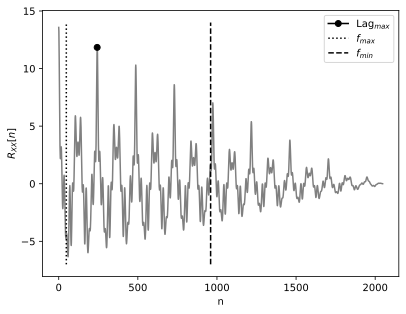

In [23]:
url = 'https://ringbuffer.org/download/ringbuffer_data/Sound_Synthesis_Introduction/Audio/SampLib_BuK_04.mp3'
x, fs = sf.read(io.BytesIO(urlopen(url).read()))

x1 = x[50000:50000+2048]
corr = np.correlate(x1, x1, mode='full')
corr = corr[len(corr)//2:]  # Keep only the second half

min_freq=50
max_freq=1000

# Define the search range
min_lag = int(fs / max_freq)
max_lag = int(fs / min_freq)

# Find the peak in the valid range
peak_index = np.argmax(corr[min_lag:max_lag]) + min_lag
pitch = fs / peak_index
 
plt.plot(x1,'gray')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.show()

plt.plot(corr ,'gray')
plt.plot(peak_index,corr[peak_index], 'k',marker='o', label='$\mathrm{Lag}_{max}$');
plt.xlabel('n')
plt.ylabel('$R_{XX}[n]$');


plt.plot([min_lag,min_lag],[-7,14],'k:', label="$f_{max}$")
plt.plot([max_lag,max_lag],[-7,14],'k--', label="$f_{min}$")

plt.legend();


In the search domain, the autocorrelation fuction has the highest significant peak at:

$$
\mathrm{Lag}_{max}=243
$$


The fundamental frequency in Hz can be obtained by the following equation:

$$
f_0 = \frac{f_s}{\mathrm{Lag}_{max}} = 197.53 \mathrm{Hz}
$$